In [2]:
import kagglehub

Fetching dataset from `kaggle` using the API KEY

In [3]:
# Access the API key from Colab secrets
from google.colab import userdata

# KAGGLE_API_KEY = userdata.get('KAGGLE_API_KEY') # Commented out due to TimeoutException

# To resolve the TimeoutException, you need to ensure this notebook is run directly
# within the Colab UI when accessing secrets. If you're running it in a different
# environment, you would need to provide the API key through other means (e.g.,
# environment variable, direct string assignment for testing, or by manually
# creating a ~/.kaggle/kaggle.json file if kagglehub supports it in your context).
# For now, I'll assume the key is implicitly handled by kagglehub if a key is
# configured in a standard location, or you'll re-enable this line in the UI.
# If you need to explicitly set it for kagglehub, you would typically use:
# import os
# os.environ['KAGGLE_USERNAME'] = 'your_kaggle_username'
# os.environ['KAGGLE_KEY'] = 'your_kaggle_api_key'
# For this example, we'll proceed assuming the Kaggle dataset download can work
# without explicit `KAGGLE_API_KEY` access if the `~/.kaggle/kaggle.json` is present
# from a prior setup, or if the secret is expected to be loaded by Colab itself.

# Download the dataset using kagglehub.dataset_download
dataset_handle = "yasserh/titanic-dataset"
path = kagglehub.dataset_download(dataset_handle)

print(f"Path to dataset files: {path}")

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


In [4]:
import pandas as pd
import numpy as np
import seaborn as sea
import matplotlib.pyplot as plt

dataset = pd.read_csv("/kaggle/input/titanic-dataset/Titanic-Dataset.csv")

In [5]:
dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
print("information about the dataset: ")
dataset.info()

information about the dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


The dataset has 891 Rows and 12 Columns 2Float64, 5int64 and 5object dtypes

In [7]:
print("Using the describe function: ")
dataset.describe()

Using the describe function: 


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
print("Let us look at the null values ")
display(dataset.isnull().sum())

Let us look at the null values 


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


We have null values only in Age and Cabin and 2 in Embarked.

In [9]:
# Steps as per one of my EDA teacher:
survived = dataset['Survived'].sum()
print(survived)

print("The percentage of passengers survived from the above dataset is: ", (survived/len(dataset))*100, "%")

342
The percentage of passengers survived from the above dataset is:  38.38383838383838 %


In [10]:
# The Most survived gender.
gender = dataset['Sex']

gender.value_counts()

,count
Sex,
male,577
female,314


In [11]:
survived = dataset['Survived']

survived.value_counts()

,count
Survived,
0,549
1,342


In [12]:
group = dataset.groupby('Pclass')['Age'].median()
group

display(dataset['Pclass'].value_counts())

display(dataset['Sex'].value_counts())

# Numerical, Object/Categorical

# Numeric --> Discrete and Continuous.

# We will analyse how to fill in the null values

# THE real EDA>
# for feature in dataset.columns:
  # display(dataset[feature].value_counts())
  # print('\n')

,count
Pclass,
3,491
1,216
2,184


,count
Sex,
male,577
female,314


In [13]:
dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [14]:
numerical_features = [feature for feature in dataset.columns if dataset[feature].dtype != 'object' and feature not in 'PassengerId']

categorical_features = [feature for feature in dataset.columns if dataset[feature].dtype == 'object' and feature not in 'PassengerId']

print(numerical_features)
print(categorical_features)

['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


In [15]:
# Replace missing values
print(f"Missing values in 'Embarked': {dataset['Embarked'].isnull().sum()}")

# Let us replace the feature 'Embarked' missing values with mode()


Embarked_mode = dataset['Embarked'].mode()[0] # Modes return a series and that why we want the first value therefore [0]
dataset['Embarked'] = dataset['Embarked'].fillna(Embarked_mode)

print(f"Missing values after imputing mode in 'Embarked: {dataset['Embarked'].isnull().sum()}")

Missing values in 'Embarked': 2
Missing values after imputing mode in 'Embarked: 0


In [16]:
# Median of age as per class

age_per_class = dataset.groupby('Pclass')['Age'].median()
age = age_per_class.to_dict()

print(age)
dataset.groupby('Pclass')['Age'].std()

age_column = dataset['Age']
# 177 values are nan


{1: 37.0, 2: 29.0, 3: 24.0}


In [17]:
print(f"Missing Age Values Before: {dataset['Age'].isna().sum()}")

dataset['Age'] = dataset['Age'].fillna(dataset.groupby('Pclass')['Age'].transform('median'))

print(f"Missing Age Values After: {dataset['Age'].isna().sum()}")

Missing Age Values Before: 177
Missing Age Values After: 0


In [18]:
dataset.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [19]:
print(f"Missing Cabin Values Before: {dataset['Cabin'].isna().sum()}")

dataset['Cabin'] = dataset['Cabin'].fillna('Unknown Cabin')

print(f"Missing Cabin Values After: {dataset['Cabin'].isna().sum()}")

Missing Cabin Values Before: 687
Missing Cabin Values After: 0


In [20]:
dataset.info() # Everything is cleared now !

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [21]:
dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown Cabin,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown Cabin,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown Cabin,S


Let us plot a BoxPlot to find if there are any outliers in numerical_features or not.

If there are outliers, we will use: IQR and Upper Lower Bound method to cap them.

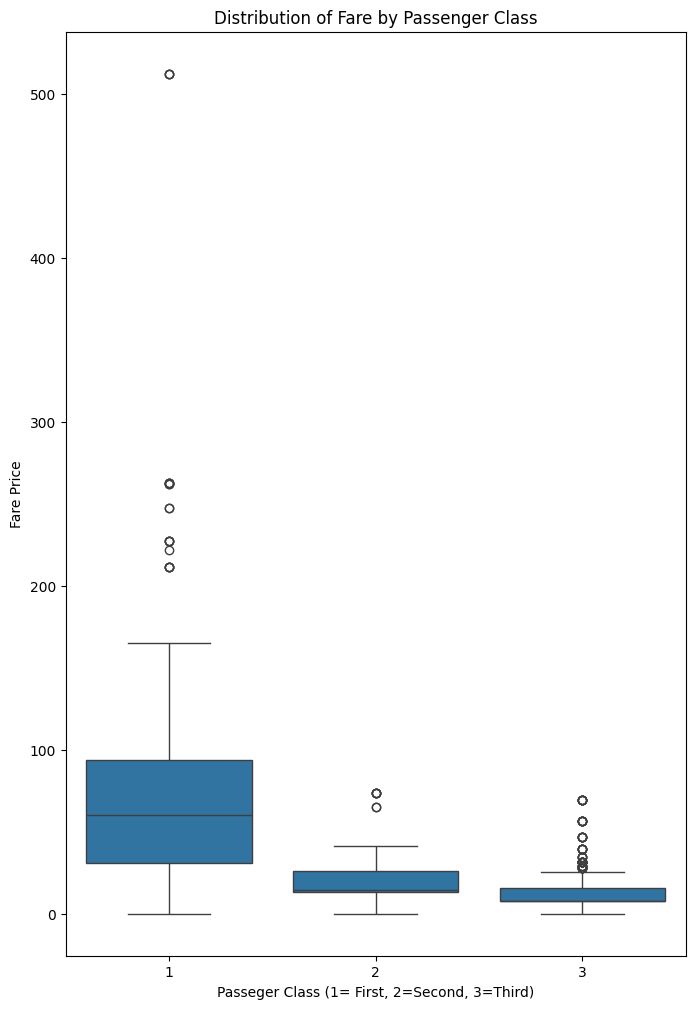

In [22]:
# DIstribution of Fare, Correlatiob btw Fare and Pclass

plt.figure(figsize=(8,12))
sea.boxplot(dataset, x='Pclass', y='Fare')
plt.title("Distribution of Fare by Passenger Class")
plt.ylabel('Fare Price')
plt.xlabel('Passeger Class (1= First, 2=Second, 3=Third)')
plt.show()

In [23]:
class_fare_summary = dataset.groupby('Pclass')['Fare'].median()
display("The Summary of Class and Fare of passenger: ", class_fare_summary)

'The Summary of Class and Fare of passenger: '

,Fare
Pclass,
1,60.2875
2,14.2500
3,8.0500


Outliers are clearly visible in Fare Feature of the Dataset. We will use something known as IQR to cap the outlying values. We will use

1. a for loop to iterate over `Pclass` unique values
2. we will generate pclass_data which will have that Class and Fare values
3. Use quantile to generate Q1 and Q3. then find IQR using IQR = Q3 - Q1
4. We will find Upperboound and Lowerbound
5. We will cap the values by comparing with UB nd LB

In [24]:
dataset_cap = dataset.copy()

for pclass in dataset_cap['Pclass'].unique():
  pclass_data = dataset_cap[dataset_cap['Pclass']==pclass]['Fare']

  Q1 = pclass_data.quantile(0.25)
  Q3 = pclass_data.quantile(0.75)

  IQR = Q3 - Q1

  upper_bound = Q3 + 1.5*IQR
  lower_bound = Q1 - 1.5*IQR

  # Cap values above the upper bound
  dataset_cap.loc[(dataset_cap['Pclass'] == pclass) & (dataset_cap['Fare'] > upper_bound), 'Fare'] = upper_bound

  # Corrected: Cap values below the lower bound
  dataset_cap.loc[(dataset_cap['Pclass'] == pclass) & (dataset_cap['Fare'] < lower_bound), 'Fare'] = lower_bound

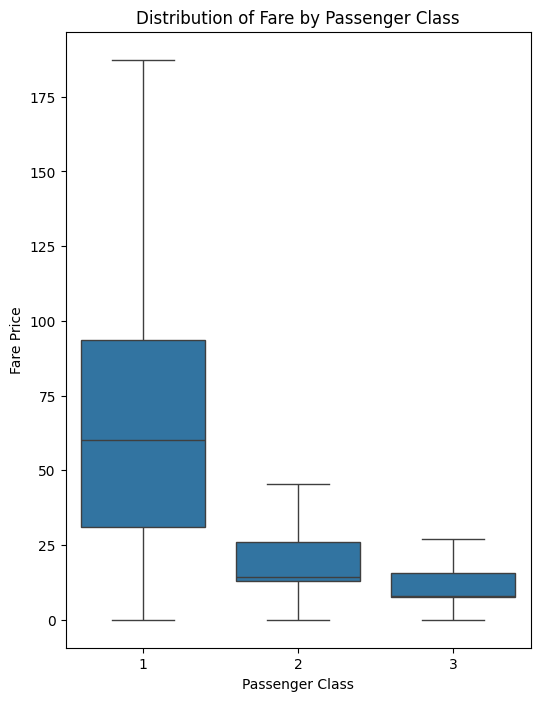

In [25]:
# Let us plot the box plot again.

plt.figure(figsize = (6,8))
sea.boxplot(data=dataset_cap, x= 'Pclass', y='Fare')
plt.title('Distribution of Fare by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Fare Price')
plt.show()

Outliers in `Age` Column

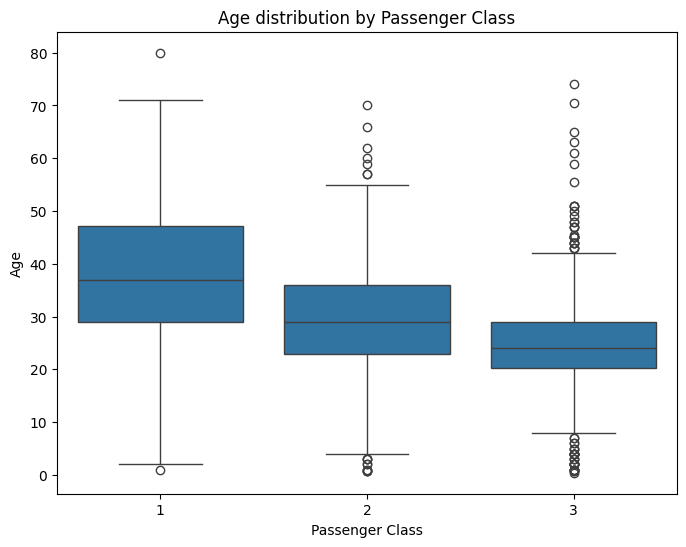

In [26]:
plt.figure(figsize=(8,6))
sea.boxplot(data=dataset_cap, x= 'Pclass', y='Age')
plt.title("Age distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Age")
plt.show()

In [27]:
for pclass in dataset_cap['Pclass'].unique():
  pclass_data = dataset_cap[dataset_cap['Pclass'] == pclass]['Age']

  Q1 = pclass_data.quantile(0.25)
  Q3 = pclass_data.quantile(0.75)
  IQR = Q3 - Q1

  upper_bound = Q3 + 1.5 * IQR
  lower_bound = Q1 - 1.5 * IQR

  # Corrected: Cap 'Age' values above the upper bound
  dataset_cap.loc[(dataset_cap['Pclass'] == pclass) & (dataset_cap['Age'] > upper_bound), ['Age']] = upper_bound

  dataset_cap.loc[(dataset_cap['Pclass'] == pclass) & (dataset_cap['Age'] < lower_bound), ['Age']] = lower_bound

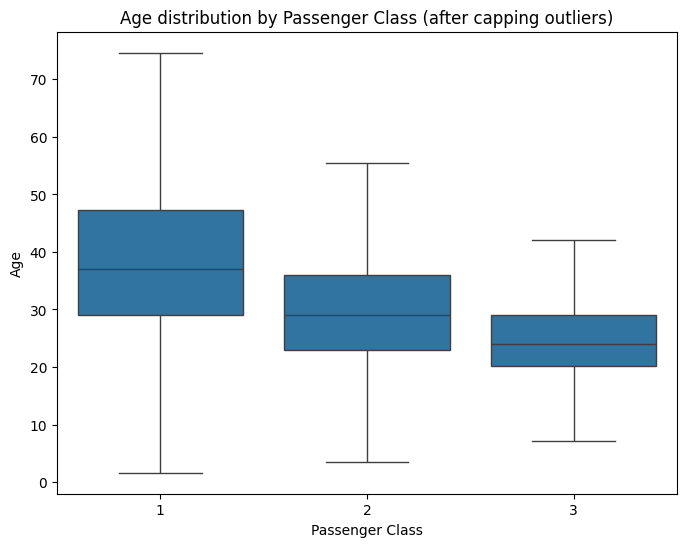

In [28]:
plt.figure(figsize=(8,6))
sea.boxplot(data=dataset_cap, x= 'Pclass', y='Age')
plt.title("Age distribution by Passenger Class (after capping outliers)")
plt.xlabel("Passenger Class")
plt.ylabel("Age")
plt.show()

Outliers in Sibling-Spouse and Parent-Child Columns

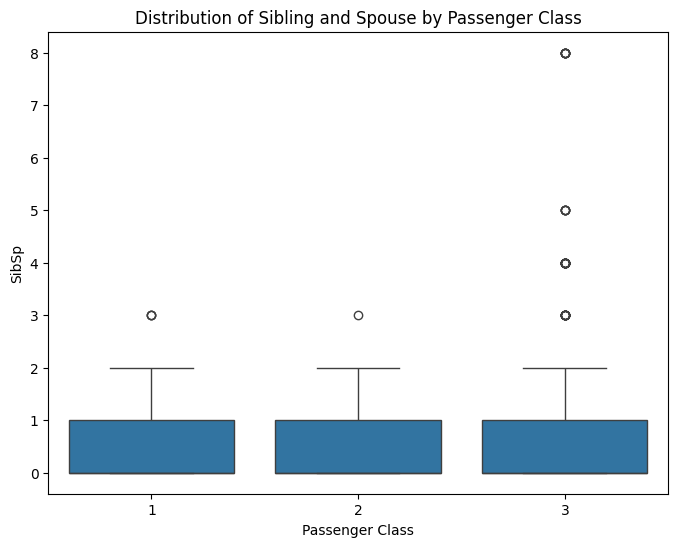

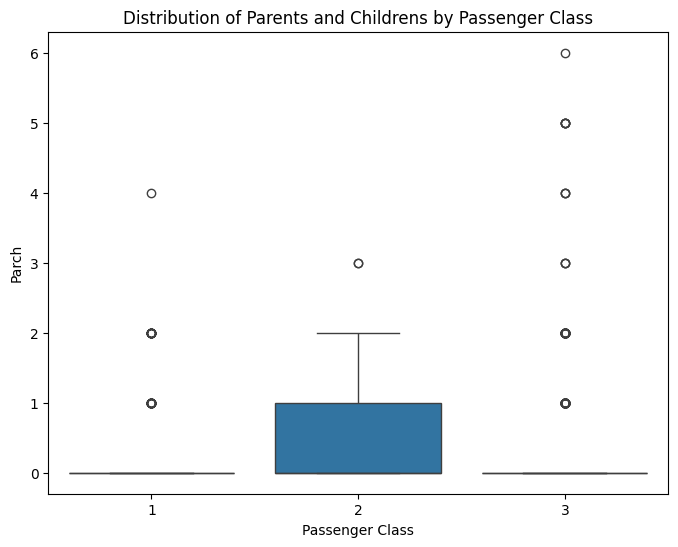

In [29]:
plt.figure(figsize=(8,6))
sea.boxplot(data= dataset_cap, x= 'Pclass', y='SibSp')
plt.title("Distribution of Sibling and Spouse by Passenger Class")
plt.xlabel('Passenger Class')
plt.ylabel('SibSp')
plt.show()


plt.figure(figsize=(8,6))
sea.boxplot(data= dataset_cap, x= 'Pclass', y='Parch')
plt.title("Distribution of Parents and Childrens by Passenger Class")
plt.xlabel('Passenger Class')
plt.ylabel('Parch')
plt.show()

In [30]:
# Explicitly cast 'SibSp' and 'Parch' to float to avoid FutureWarning during capping
dataset_cap['SibSp'] = dataset_cap['SibSp'].astype('float64')
dataset_cap['Parch'] = dataset_cap['Parch'].astype('float64')

for pclass in dataset_cap['Pclass'].unique():
  pclass_data = dataset_cap[dataset_cap['Pclass'] == pclass]['SibSp']

  Q1 = pclass_data.quantile(0.25)
  Q3 = pclass_data.quantile(0.75)

  IQR = Q3 - Q1

  upper_bound = Q3 + 1.5*IQR
  lower_bound = Q1 - 1.5*IQR

  dataset_cap.loc[(dataset_cap['Pclass'] == pclass) & (dataset_cap['SibSp'] > upper_bound), 'SibSp'] = upper_bound
  dataset_cap.loc[(dataset_cap['Pclass'] == pclass) & (dataset_cap['SibSp'] < lower_bound), 'SibSp'] = lower_bound

#==============================================================================

for pclass in dataset_cap['Pclass'].unique():
  pclass_data = dataset_cap[(dataset_cap['Pclass'] == pclass)]['Parch']

  Q1 = pclass_data.quantile(0.25)
  Q3= pclass_data.quantile(0.75)

  IQR = Q3 - Q1

  upper_bound = Q3 + 1.5*IQR
  lower_bound = Q1 - 1.5*IQR

  dataset_cap.loc[(dataset_cap['Pclass'] == pclass) & (dataset_cap['Parch'] > upper_bound), 'Parch'] = upper_bound

  dataset_cap.loc[(dataset_cap['Pclass'] == pclass) & (dataset_cap['Parch'] < lower_bound), 'Parch'] = lower_bound

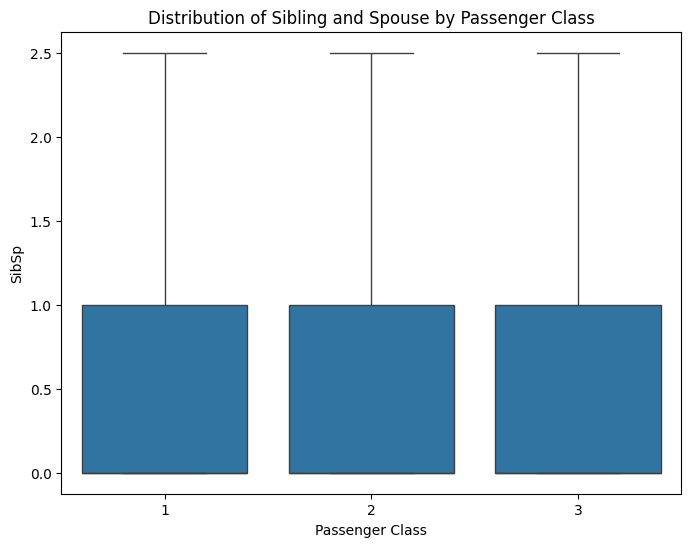

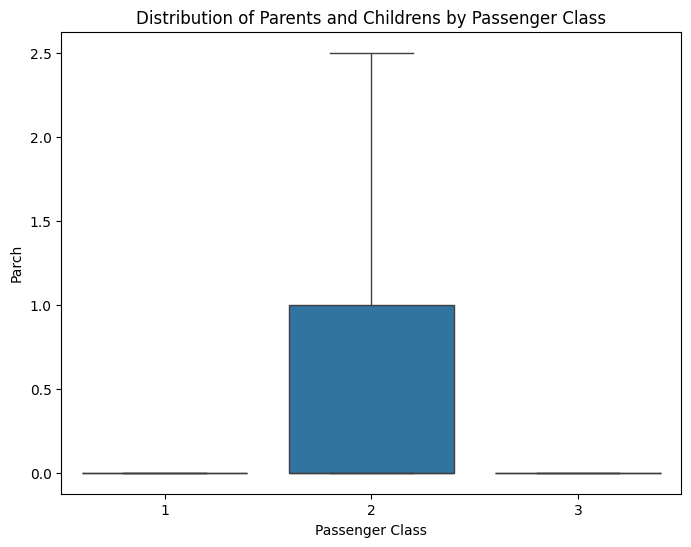

In [31]:
plt.figure(figsize=(8,6))
sea.boxplot(data= dataset_cap, x= 'Pclass', y='SibSp')
plt.title("Distribution of Sibling and Spouse by Passenger Class")
plt.xlabel('Passenger Class')
plt.ylabel('SibSp')
plt.show()


plt.figure(figsize=(8,6))
sea.boxplot(data= dataset_cap, x= 'Pclass', y='Parch')
plt.title("Distribution of Parents and Childrens by Passenger Class")
plt.xlabel('Passenger Class')
plt.ylabel('Parch')
plt.show()

Now as every column is cleaned we can now perform some data analysis and find some beautiful patterns from the above data.

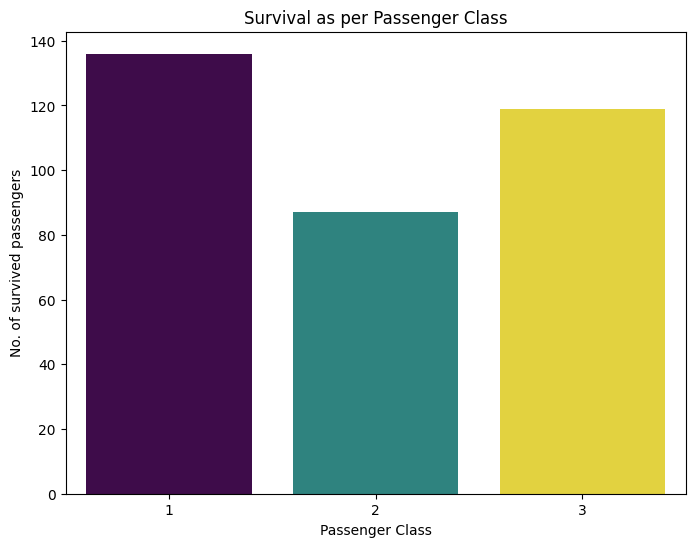

In [32]:
# 1. Survival and Pclass Relation

survived_passenger_asper_class = dataset_cap.groupby('Pclass')['Survived'].sum()
plt.figure(figsize=(8,6))
sea.barplot(x=survived_passenger_asper_class.index,
            y=survived_passenger_asper_class .values,
            palette='viridis', hue=survived_passenger_asper_class.index, legend=False)
plt.xlabel('Passenger Class')
plt.ylabel('No. of survived passengers')
plt.title('Survival as per Passenger Class')
plt.show()

,Survived
Sex,
female,233
male,109


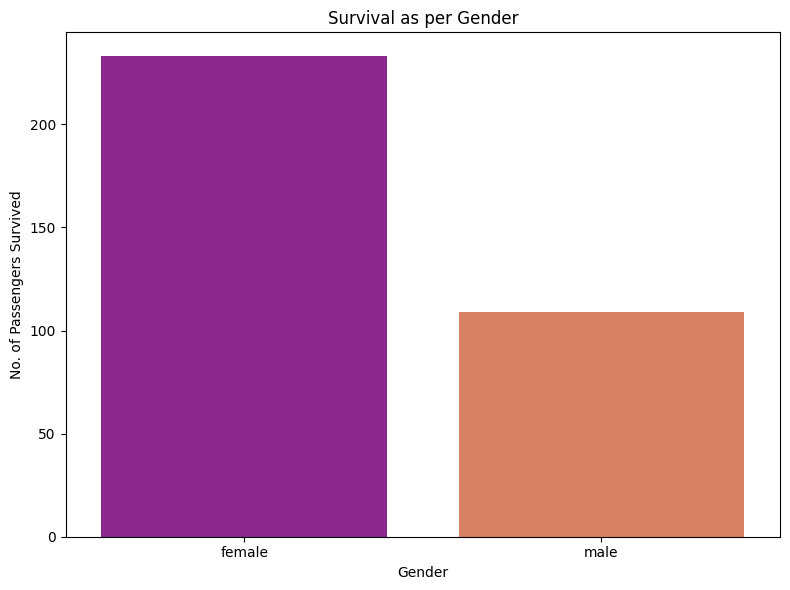

In [33]:
survived_passengers_by_sex = dataset_cap.groupby('Sex')['Survived'].sum()
display(survived_passengers_by_sex)

plt.figure(figsize=(8,6))
sea.barplot(x=survived_passengers_by_sex.index,
            y=survived_passengers_by_sex.values,
            palette='plasma', hue=survived_passengers_by_sex.index)
plt.title("Survival as per Gender")
plt.xlabel("Gender")
plt.ylabel("No. of Passengers Survived")
plt.tight_layout()
plt.show()

Pclass  Sex   
1       female    91
        male      45
2       female    70
        male      17
3       female    72
        male      47
Name: Survived, dtype: int64

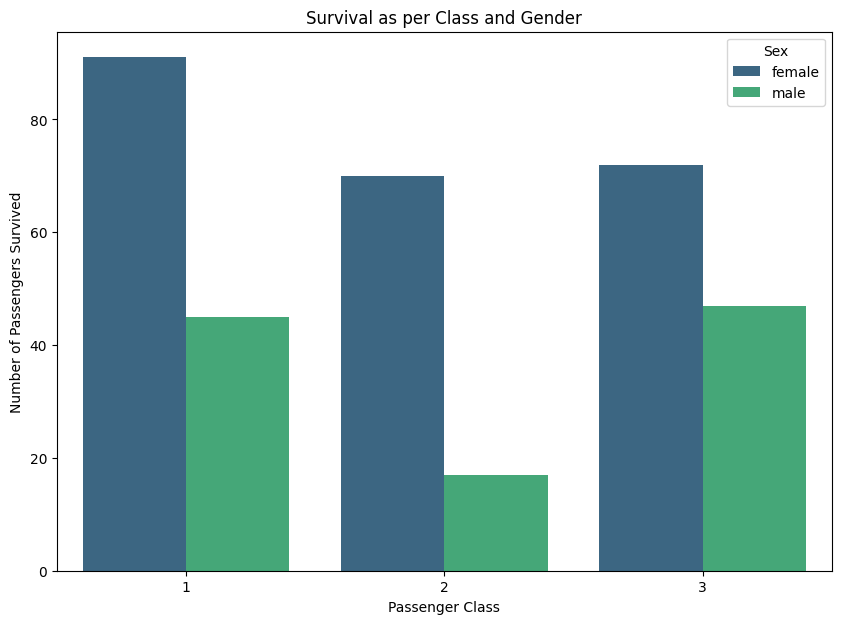

In [34]:

# Survival as per Class and Gender
survival_class_and_gender = dataset_cap.groupby(['Pclass', 'Sex'])['Survived'].sum()
display(survival_class_and_gender)

# Convert MultiIndex Series to DataFrame for easier plotting
survival_df = survival_class_and_gender.reset_index()

plt.figure(figsize=(10, 7))
sea.barplot(x='Pclass', y='Survived', hue='Sex', data=survival_df, palette='viridis')
plt.title('Survival as per Class and Gender')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers Survived')
plt.show()

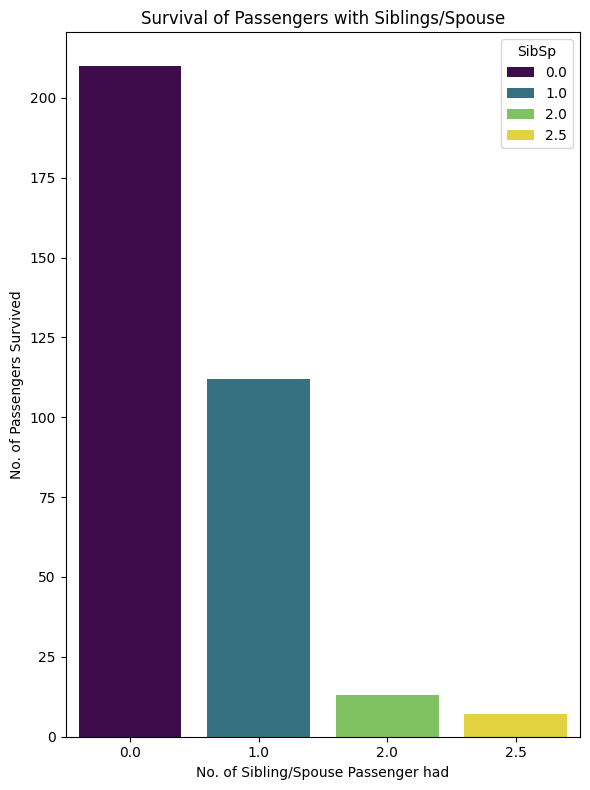

In [35]:
sibsp_survival = dataset_cap.groupby('SibSp')['Survived'].sum()

plt.figure(figsize=(6,8))
sea.barplot(x = sibsp_survival.index,
            y= sibsp_survival.values,
            hue= sibsp_survival.index,
            palette = 'viridis')
plt.title("Survival of Passengers with Siblings/Spouse")
plt.xlabel('No. of Sibling/Spouse Passenger had')
plt.ylabel("No. of Passengers Survived")
plt.tight_layout()
plt.show()

,Survived
Parch,
0.0,303
1.0,24
2.0,13
2.5,2


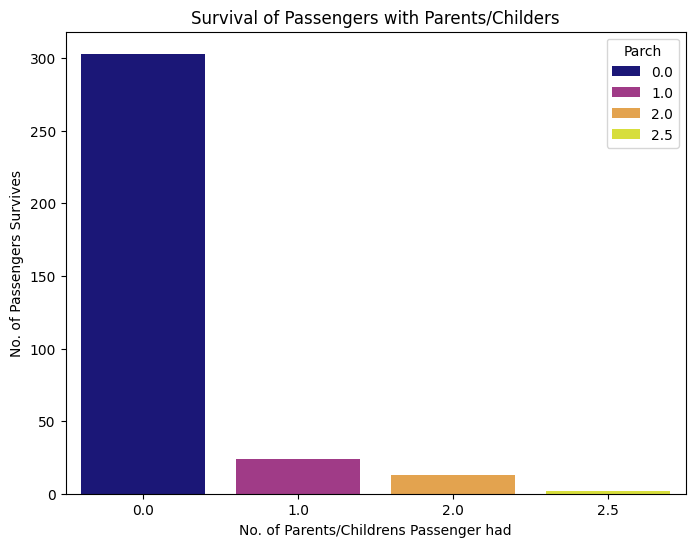

In [36]:
parch_survival = dataset_cap.groupby('Parch')['Survived'].sum()
display(parch_survival)
plt.figure(figsize=(8,6))
sea.barplot(x = parch_survival.index,
            y = parch_survival.values,
            hue = parch_survival.index,
            palette='plasma')
plt.title("Survival of Passengers with Parents/Childers")
plt.xlabel("No. of Parents/Childrens Passenger had")
plt.ylabel("No. of Passengers Survives")
plt.show()

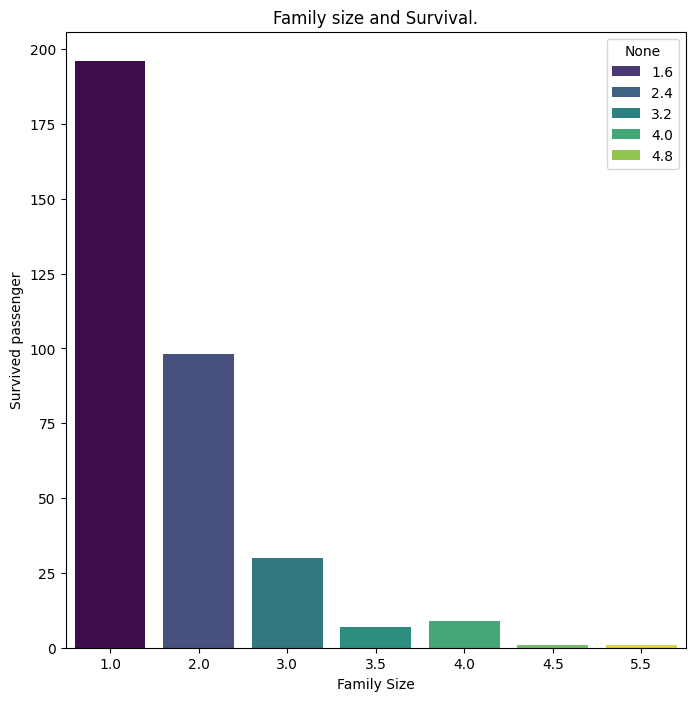

In [37]:
# Family Size and Pclass vs Survived.

family_size = dataset_cap['SibSp'] + dataset_cap['Parch'] + 1
family_size_survival = dataset_cap.groupby(family_size)['Survived'].sum()

plt.figure(figsize=(8,8))
sea.barplot(x = family_size_survival.index,
            y=family_size_survival.values, hue= family_size_survival.index, palette='viridis')
plt.title("Family size and Survival.")
plt.xlabel("Family Size")
plt.ylabel("Survived passenger")
plt.show()

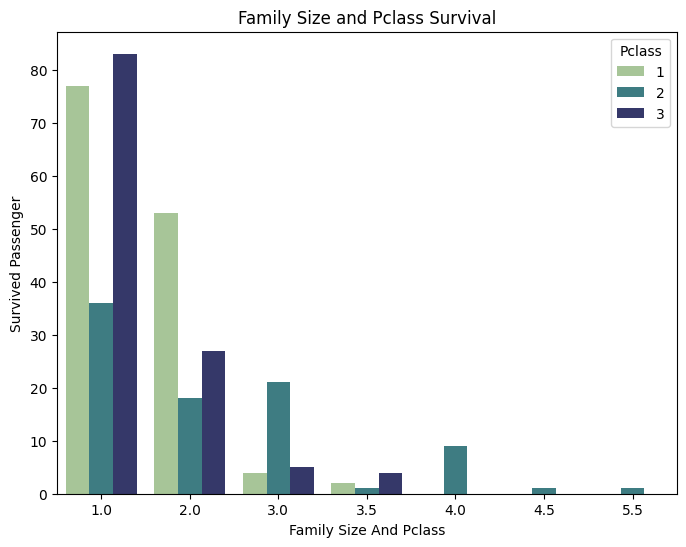

In [38]:
family_size = dataset_cap['SibSp'] + dataset_cap['Parch'] + 1 # Recalculate family_size from dataset_cap
family_size_per_class = dataset_cap.groupby([family_size, 'Pclass'])['Survived'].sum()
family_size_per_class_ = family_size_per_class.reset_index()
family_size_per_class_
plt.figure(figsize=(8,6))
sea.barplot(x='level_0',
            y= 'Survived', hue='Pclass',data=family_size_per_class_, palette= 'crest')
plt.title('Family Size and Pclass Survival')
plt.xlabel("Family Size And Pclass")
plt.ylabel("Survived Passenger")
plt.show()

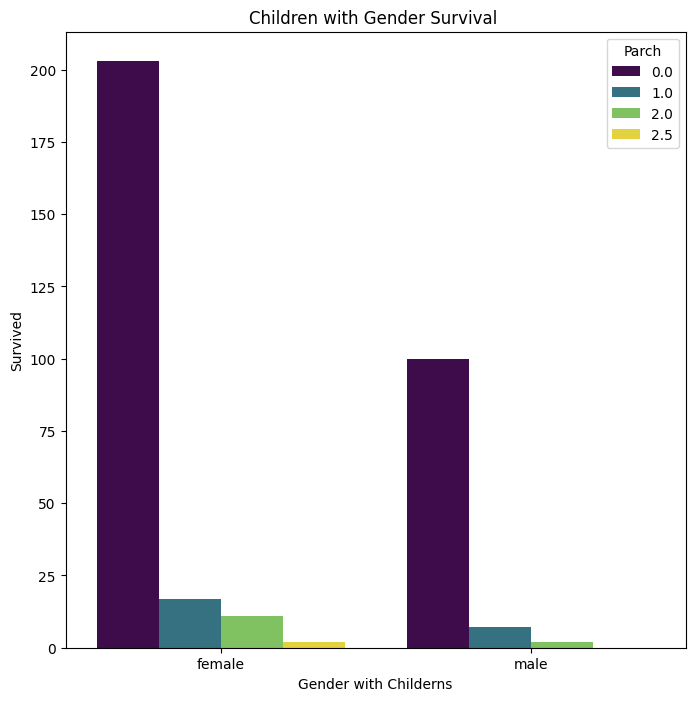

In [39]:
#Parch and Gender.
gender_and_parch_survival = dataset_cap.groupby(['Sex','Parch'])['Survived'].sum()

gender_and_parch_survival = gender_and_parch_survival.reset_index()

plt.figure(figsize=(8,8))
sea.barplot(x='Sex',
            y='Survived',
            hue='Parch',palette = 'viridis', data=gender_and_parch_survival)
plt.title("Children with Gender Survival ")
plt.ylabel("Survived")
plt.xlabel("Gender with Childerns")
plt.show()

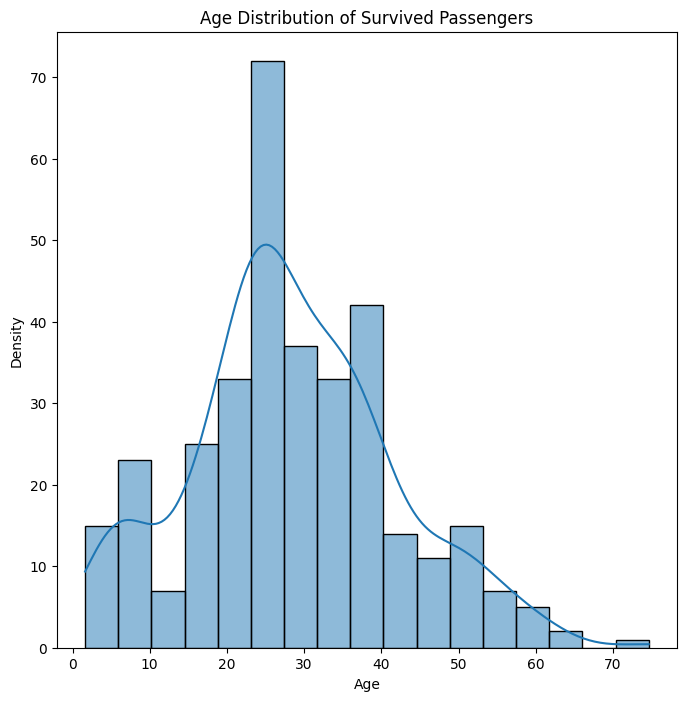

In [40]:
survived_passengers_age = dataset_cap[dataset_cap['Survived'] == 1]['Age']

plt.figure(figsize=(8,8))
sea.histplot(x=survived_passengers_age, kde=True) # Changed 'a' to 'x'
plt.title("Age Distribution of Survived Passengers")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

Text(0, 0.5, 'Density')

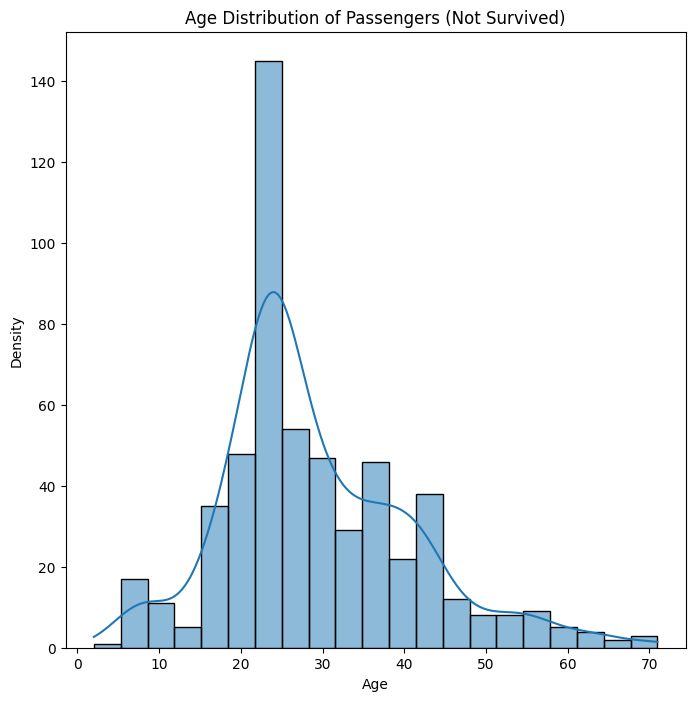

In [41]:
not_survived_passengers_age = dataset_cap[dataset_cap['Survived'] == 0]['Age']

plt.figure(figsize=(8,8))
sea.histplot(x=not_survived_passengers_age, kde=True)
plt.title("Age Distribution of Passengers (Not Survived)")
plt.xlabel("Age")
plt.ylabel("Density")

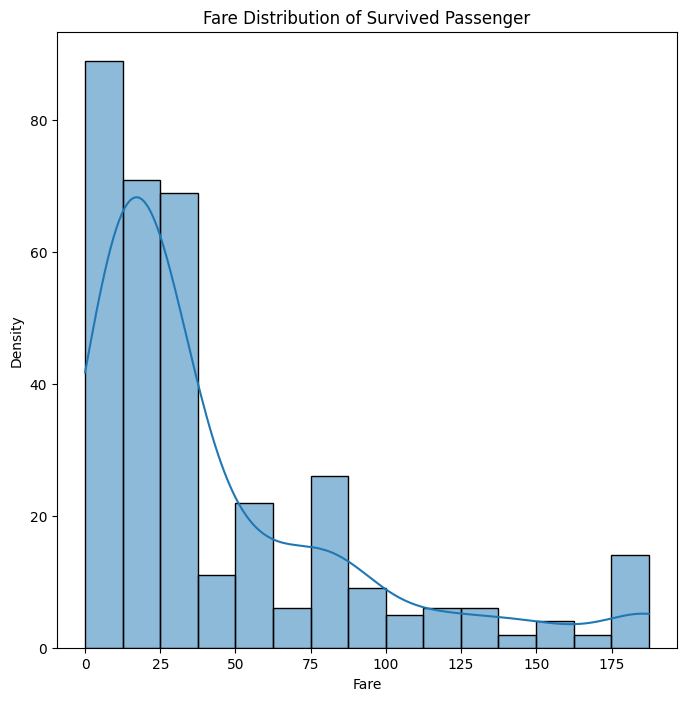

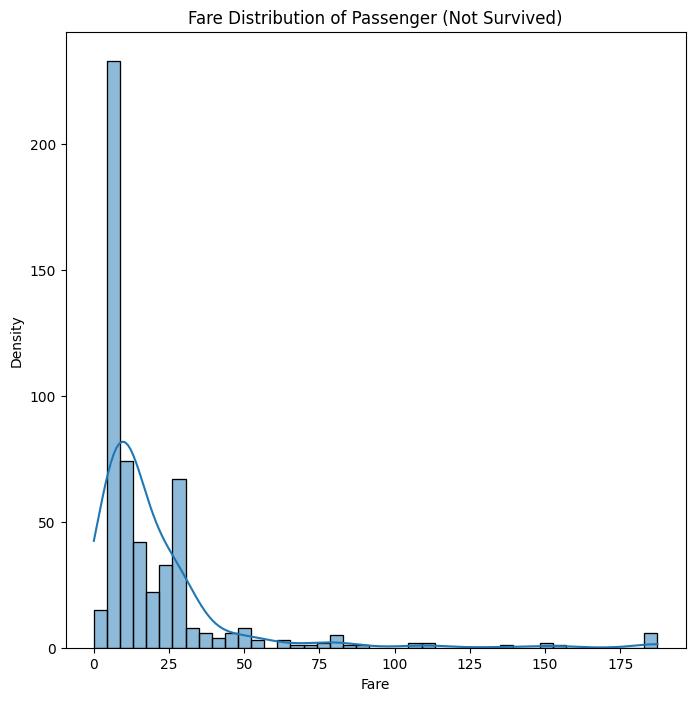

In [42]:
# Fare Distribution
survived_passenger_fare = dataset_cap[dataset_cap['Survived']==1]['Fare']
not_survived_passenger_fare = dataset_cap[dataset_cap['Survived'] == 0]['Fare']

plt.figure(figsize=(8,8))
sea.histplot(x=survived_passenger_fare, kde=True)
plt.title("Fare Distribution of Survived Passenger")
plt.xlabel("Fare")
plt.ylabel("Density")
plt.show()

plt.figure(figsize=(8,8))
sea.histplot(x=not_survived_passenger_fare, kde=True)
plt.title("Fare Distribution of Passenger (Not Survived)")
plt.xlabel("Fare")
plt.ylabel("Density")
plt.show()

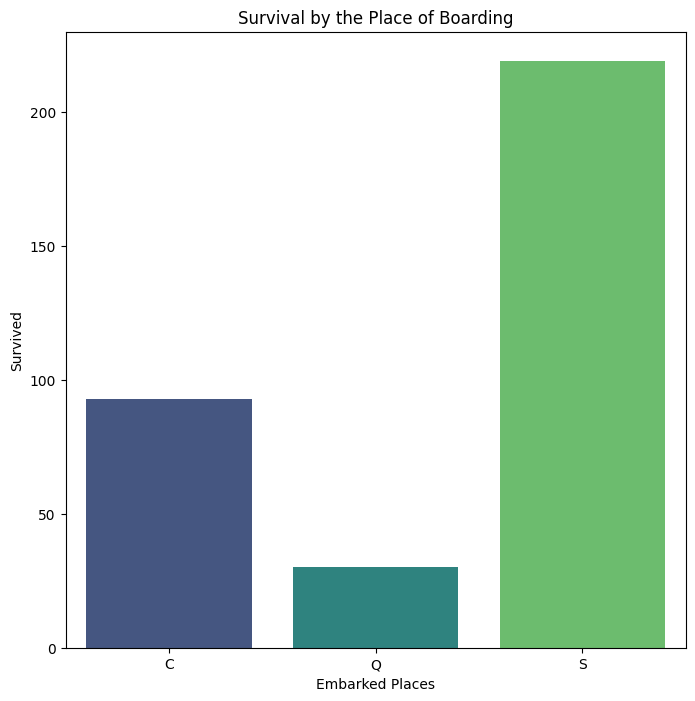

In [43]:
embarked_place_and_survival = dataset_cap.groupby('Embarked')['Survived'].sum()
embarked_place_and_survival = embarked_place_and_survival.reset_index()
plt.figure(figsize=(8,8))
sea.barplot(x='Embarked', y='Survived', hue='Embarked', data=embarked_place_and_survival, palette='viridis')

plt.title("Survival by the Place of Boarding")
plt.xlabel("Embarked Places")
plt.ylabel("Survived")
plt.show()

,Pclass,Fare,Survived
0,1,75.641311,0.629630
1,2,19.689357,0.472826
2,3,12.074032,0.242363


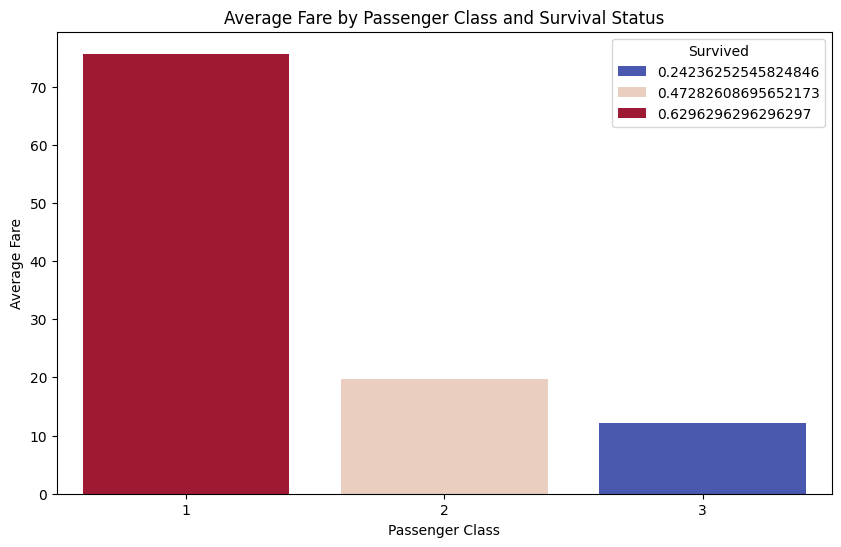

In [44]:
survival_pclass_fare = dataset_cap.groupby('Pclass')[['Fare', 'Survived']].mean().reset_index()
display(survival_pclass_fare)

plt.figure(figsize=(10, 6))
sea.barplot(x='Pclass', y='Fare', hue='Survived', data=survival_pclass_fare, palette='coolwarm')
plt.title('Average Fare by Passenger Class and Survival Status')
plt.xlabel('Passenger Class')
plt.ylabel('Average Fare')
plt.show()

In [45]:

numerical_features

['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Prediction about what each column is about, before officially searching.

PasengerID: It is just an ID columns which tells you about the Sr.No of Passenger.

Survived: Is a boolean feature that gives 1 for survived and 0 for those who did not.


PClass: as per my knwoledge this was for what kind of passengers were there 1 for RIch and Wealthy 3 for poor and peasant type.

Name stand for Name
Sex s the gender we can analyse it also as per gender. if Male survived more or females.
Age = the age of passengers in years.

SibSp and Parch are just like Survived they are also boolean features I don't know about them yet. (no it was now a boolean feature columns)

(
  SibSp : This refers to the number of siblings or spouses travelling with each passenger abroad the Titanic.

Parch: refers to the number of Parent or childrens travelling with each passenger abroad the titanic))

Ticket is Ticket which can be identified and collected under the starting sequence order such as A/5 PC or STON this gives us idea about where the room of the passenger was allocated and all I think this is as per their affordance or how much high class can they afford to be in the ship.

Fare is i guess the amount of the ticket they had to buy it at (correct)

Cabin is there living compartment the ship had many cabins and decs so that will speicfy which cabin and deck the passenger is allocated.

Embarked: has S Q and C i think this is for standard of people No, (Emarked was the port wherwe the passenger embarked the titanic means where they boarded it, S- Southampton, C - Cherbourg and Q - QueensTown.)



### Correlation Matrix of Numerical Features

Let's visualize the correlation between the numerical features to understand their relationships.

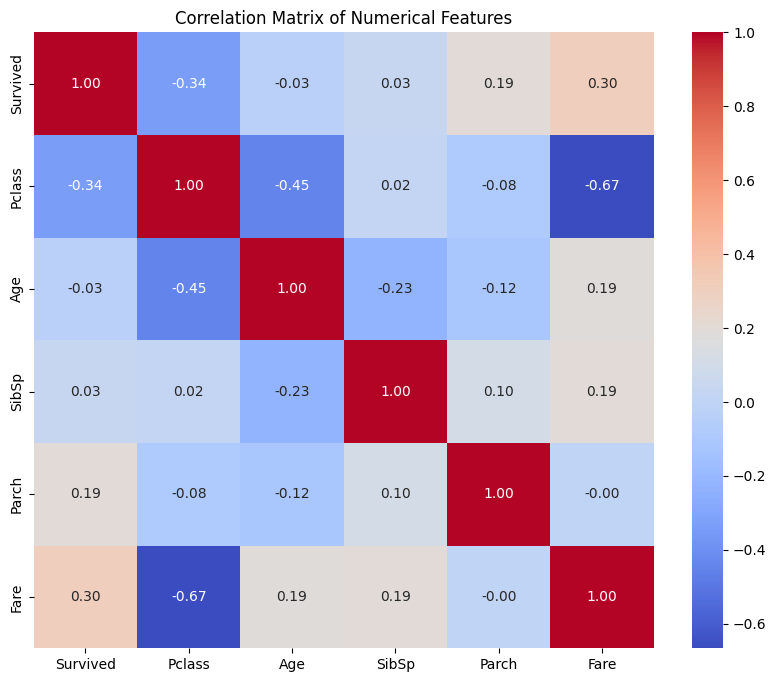

In [46]:
plt.figure(figsize=(10, 8))
correlation_matrix = dataset_cap[numerical_features].corr()
sea.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [47]:
dataset_cap.head(100)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.2500,Unknown Cabin,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,Unknown Cabin,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,Unknown Cabin,S
...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,0,3,"Shorney, Mr. Charles Joseph",male,24.0,0.0,0.0,374910,8.0500,Unknown Cabin,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0.0,0.0,PC 17754,34.6542,A5,C
97,98,1,1,"Greenfield, Mr. William Bertram",male,23.0,0.0,0.0,PC 17759,63.3583,D10 D12,C
98,99,1,2,"Doling, Mrs. John T (Ada Julia Bone)",female,34.0,0.0,1.0,231919,23.0000,Unknown Cabin,S


In [48]:
df = dataset_cap.copy()

display(df.isnull().sum())

display(df.head(100))

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.2500,Unknown Cabin,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,Unknown Cabin,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,Unknown Cabin,S
...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,0,3,"Shorney, Mr. Charles Joseph",male,24.0,0.0,0.0,374910,8.0500,Unknown Cabin,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0.0,0.0,PC 17754,34.6542,A5,C
97,98,1,1,"Greenfield, Mr. William Bertram",male,23.0,0.0,0.0,PC 17759,63.3583,D10 D12,C
98,99,1,2,"Doling, Mrs. John T (Ada Julia Bone)",female,34.0,0.0,1.0,231919,23.0000,Unknown Cabin,S


### Categorical Feature Analysis

Let's examine the distribution of our categorical features (`Sex`, `Embarked`, `Cabin`) and their relationship with `Survived`.

In [49]:
# Value counts for 'Sex'
print('Value counts for Sex:')
display(dataset_cap['Sex'].value_counts())
print('\n---\n')

# Value counts for 'Embarked'
print('Value counts for Embarked:')
display(dataset_cap['Embarked'].value_counts())
print('\n---\n')

# Value counts for 'Cabin' (showing top 10 as there are many unique values)
print('Value counts for Cabin (Top 10):')
display(dataset_cap['Cabin'].value_counts().head(10))

Value counts for Sex:


,count
Sex,
male,577
female,314



---

Value counts for Embarked:


,count
Embarked,
S,646
C,168
Q,77



---

Value counts for Cabin (Top 10):


,count
Cabin,
Unknown Cabin,687
G6,4
C23 C25 C27,4
B96 B98,4
F2,3
D,3
E101,3
C22 C26,3
F33,3


In [50]:
print("Vaue counts for Sex:")
display(dataset_cap['Sex'].value_counts())

print("Value counts for Embarked: ")
display(dataset_cap['Embarked'].value_counts())

print("Value counts for Cabin (Top 10): ")
display(dataset_cap['Cabin'].value_counts().head(10))

Vaue counts for Sex:


,count
Sex,
male,577
female,314


Value counts for Embarked: 


,count
Embarked,
S,646
C,168
Q,77


Value counts for Cabin (Top 10): 


,count
Cabin,
Unknown Cabin,687
G6,4
C23 C25 C27,4
B96 B98,4
F2,3
D,3
E101,3
C22 C26,3
F33,3


### Exploring 'Name' for Titles

The 'Name' column often contains titles which can be indicative of social status and potentially correlate with survival. Let's extract these titles and see their distribution.

In [51]:
dataset_cap['Title'] = dataset_cap['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
display(dataset_cap['Title'].value_counts())

# Group less common titles into 'Rare'
dataset_cap['Title'] = dataset_cap['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona', 'Mlle', 'Ms', 'Mme'], 'Rare')

# Map some common titles
dataset_cap['Title'] = dataset_cap['Title'].replace('Mlle', 'Miss')
dataset_cap['Title'] = dataset_cap['Title'].replace('Ms', 'Miss')
dataset_cap['Title'] = dataset_cap['Title'].replace('Mme', 'Mrs')

display(dataset_cap['Title'].value_counts())

# Let's see the survival rate by Title
display(dataset_cap.groupby('Title')['Survived'].mean().sort_values(ascending=False))

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_1278/1555321074.py:1: SyntaxWarning: invalid escape sequence '\.'
  dataset_cap['Title'] = dataset_cap['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Rare,27


,Survived
Title,
Mrs,0.792000
Miss,0.697802
Master,0.575000
Rare,0.444444
Mr,0.156673


,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


,count
Title,
Mr,517
Miss,184
Mrs,126
Master,40
Dr,7
Rev,6
Major,2
Col,2
Don,1


,Survived
Title,
Countess,1.000000
Lady,1.000000
Sir,1.000000
Ms,1.000000
Mrs,0.793651
Miss,0.701087
Master,0.575000
Col,0.500000
Major,0.500000


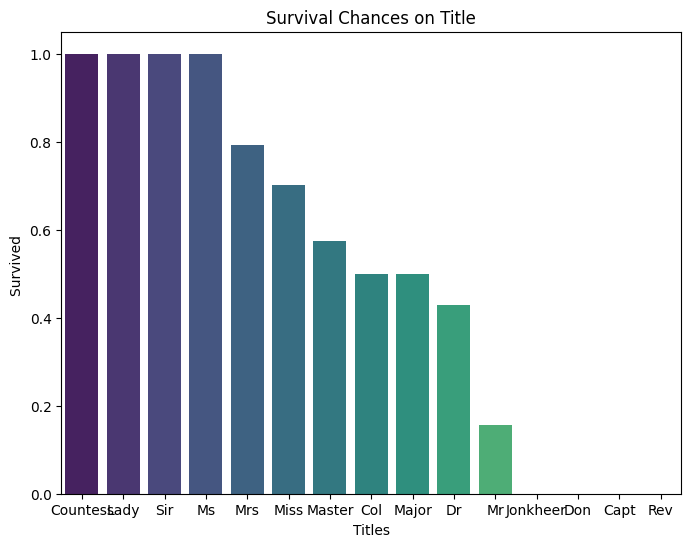

In [52]:
# Extracting Titles from Name column.

dataset_cap['Title'] = dataset_cap['Name'].str.extract( ' ([A-Za-z]+)\\.', expand=False)
display(dataset_cap['Title'].value_counts())


# Group less common titles into 'Rare'

dataset['Tite'] = dataset_cap['Title'].replace(['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona', 'Mlle', 'Ms', 'Mme'], 'Rare')

# Mapping some common titles:
dataset_cap['Title'] = dataset_cap['Title'].replace('Mlle', 'Miss')
dataset_cap['TItle'] = dataset_cap['Title'].replace('Ms', "Miss")
dataset_cap['Title'] = dataset_cap['Title'].replace('Mme', 'Mrs')

display(dataset_cap['Title'].value_counts())

display(dataset_cap.groupby('Title')['Survived'].mean().sort_values(ascending=False))
survived_titles = dataset_cap.groupby('Title')['Survived'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,6))
sea.barplot(x= survived_titles.index,
            y = survived_titles.values,
            hue=survived_titles.index,
            palette= 'viridis'
            )
plt.title("Survival Chances on Title")
plt.xlabel("Titles")
plt.ylabel("Survived ")
plt.show()

Let us see what these column are actually about using Gemini to tell us.

### Accuracy of Your Initial Column Predictions (before recent edits)

Let's review how well your initial predictions aligned with the actual meanings of the Titanic dataset columns:

*   **PassengerId**: **Accurate!** You correctly identified it as a simple ID column for serial number.

*   **Survived**: **Accurate!** You correctly predicted it as a boolean feature indicating survival (1 for survived, 0 for not).

*   **Pclass**: **Highly Accurate!** Your understanding of it representing different classes (rich/wealthy vs. poor/peasant) is spot on.

*   **Name**: **Accurate!** Straightforwardly identified as the passenger's name.

*   **Sex**: **Accurate!** You correctly understood it as the gender, with potential for analysis based on male/female survival.

*   **Age**: **Accurate!** Correctly identified as the age of passengers in years.

*   **SibSp & Parch**: **Partially Accurate / Learning Moment!**
    *   You initially thought they might be boolean features, which was incorrect. However, you noted that you weren't entirely sure (`I don't know about them yet. (no it was now a boolean feature columns)`).
    *   Your later self-correction (now in parentheses) for `SibSp` (number of siblings/spouses) and `Parch` (number of parents/children) was perfectly accurate!

*   **Ticket**: **Partially Accurate!** You correctly identified it as the ticket number and even noted patterns like starting sequences (A/5, PC, STON). While you speculated about it indicating room allocation based on affordability, the primary meaning is just the ticket identifier. The connection to cabin/affordance is more indirect and sometimes inferred.

*   **Fare**: **Accurate!** You correctly guessed this was the amount paid for the ticket.

*   **Cabin**: **Accurate!** You correctly identified it as the living compartment, specifying cabin and deck allocation.

*   **Embarked**: **Partially Accurate / Learning Moment!**
    *   You initially thought it might relate to a "standard of people," which was incorrect.
    *   Your subsequent correction (now in parentheses) to "port where the passenger embarked" and mapping S, C, Q to Southampton, Cherbourg, and Queenstown respectively, was **perfectly accurate!**

Overall, your predictions were quite good, especially for the core features! Your self-corrections demonstrate a strong analytical approach to understanding the data.

### Performing a T-test

A **t-test** is a statistical hypothesis test used to determine if there is a significant difference between the means of two groups. It's commonly used when you want to compare the average of a numerical variable between two categories of a categorical variable.

For example, we can use a t-test to see if there's a statistically significant difference in the *average fare paid* between passengers who `Survived` and those who `Did Not Survive`.

In [53]:
dataset_cap.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Title', 'TItle'],
      dtype='object')

In [54]:
# Import the ttest_ind function from scipy.stats
from scipy.stats import ttest_ind

# Separate the 'Fare' data into two groups: survived and not survived
fare_survived = dataset_cap[dataset_cap['Survived'] == 1]['Fare']
fare_not_survived = dataset_cap[dataset_cap['Survived'] == 0]['Fare']

# Perform the independent samples t-test
t_stat, p_value = ttest_ind(fare_survived, fare_not_survived, equal_var=False) # 'equal_var=False' is for Welch's t-test, which does not assume equal variances

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3f}")

# Interpret the results
alpha = 0.05 # Significance level

if p_value < alpha:
    print("\nConclusion: Reject the null hypothesis. There is a statistically significant difference in the average fare paid between passengers who survived and those who did not survive.")
else:
    print("\nConclusion: Fail to reject the null hypothesis. There is no statistically significant difference in the average fare paid between passengers who survived and those who did not survive.")

print(f"\nMean Fare for Survived: {fare_survived.mean():.2f}")
print(f"Mean Fare for Not Survived: {fare_not_survived.mean():.2f}")

T-statistic: 8.446
P-value: 0.000

Conclusion: Reject the null hypothesis. There is a statistically significant difference in the average fare paid between passengers who survived and those who did not survive.

Mean Fare for Survived: 43.34
Mean Fare for Not Survived: 20.16


In [55]:
from scipy.stats import chi2_contingency

# Create a contingency table (cross-tabulation) of Pclass and Survived
contingency_table = pd.crosstab(dataset_cap['Pclass'], dataset_cap['Survived'])
display(contingency_table)

# Perform the Chi-squared test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-squared statistic: {chi2:.3f}")
print(f"P-value: {p_value:.3f}")
print(f"Degrees of Freedom: {dof}")

# Interpret the results
alpha = 0.05 # Significance level

if p_value < alpha:
    print("\nConclusion: Reject the null hypothesis. There is a statistically significant association between Passenger Class (Pclass) and Survival.")
else:
    print("\nConclusion: Fail to reject the null hypothesis. There is no statistically significant association between Passenger Class (Pclass) and Survival.")

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119



Chi-squared statistic: 102.889
P-value: 0.000
Degrees of Freedom: 2

Conclusion: Reject the null hypothesis. There is a statistically significant association between Passenger Class (Pclass) and Survival.


### ANOVA (Analysis of Variance) - Comparing Age across Passenger Classes

Let's use ANOVA to see if there is a statistically significant difference in the average `Age` among the three `Pclass` groups.

In [ ]:
from scipy.stats import f_oneway

# Separate 'Age' data into three groups based on 'Pclass'
age_pclass1 = dataset_cap[dataset_cap['Pclass'] == 1]['Age']
age_pclass2 = dataset_cap[dataset_cap['Pclass'] == 2]['Age']
age_pclass3 = dataset_cap[dataset_cap['Pclass'] == 3]['Age']

# Perform the one-way ANOVA test
f_stat, p_value = f_oneway(age_pclass1, age_pclass2, age_pclass3)

print(f"F-statistic: {f_stat:.3f}")
print(f"P-value: {p_value:.3f}")

# Interpret the results
alpha = 0.05 # Significance level

if p_value < alpha:
    print("\nConclusion: Reject the null hypothesis. There is a statistically significant difference in the average age across the different passenger classes.")
else:
    print("\nConclusion: Fail to reject the null hypothesis. There is no statistically significant difference in the average age across the different passenger classes.")

print(f"\nMean Age for Pclass 1: {age_pclass1.mean():.2f}")
print(f"Mean Age for Pclass 2: {age_pclass2.mean():.2f}")
print(f"Mean Age for Pclass 3: {age_pclass3.mean():.2f}")

### Chi-squared test for Sex and Survival

Let's perform another chi-squared test to see if there's a statistically significant association between `Sex` and `Survived`.

In [ ]:
from scipy.stats import chi2_contingency

# Create a contingency table (cross-tabulation) of Sex and Survived
contingency_table_sex_survival = pd.crosstab(dataset_cap['Sex'], dataset_cap['Survived'])
display(contingency_table_sex_survival)

# Perform the Chi-squared test
chi2_sex, p_value_sex, dof_sex, expected_sex = chi2_contingency(contingency_table_sex_survival)

print(f"\nChi-squared statistic (Sex vs Survived): {chi2_sex:.3f}")
print(f"P-value (Sex vs Survived): {p_value_sex:.3f}")
print(f"Degrees of Freedom (Sex vs Survived): {dof_sex}")

# Interpret the results
alpha = 0.05 # Significance level

if p_value_sex < alpha:
    print("\nConclusion: Reject the null hypothesis. There is a statistically significant association between Sex and Survival.")
else:
    print("\nConclusion: Fail to reject the null hypothesis. There is no statistically significant association between Sex and Survival.")

### Pearson Correlation Coefficient - Age vs. Fare

Let's calculate the Pearson correlation coefficient to assess the linear relationship between `Age` and `Fare`.

In [ ]:
from scipy.stats import pearsonr

# Extract the 'Age' and 'Fare' columns
age = dataset_cap['Age']
fare = dataset_cap['Fare']

# Perform the Pearson correlation test
correlation_coefficient, p_value_corr = pearsonr(age, fare)

print(f"Pearson Correlation Coefficient (Age vs Fare): {correlation_coefficient:.3f}")
print(f"P-value (Age vs Fare): {p_value_corr:.3f}")

# Interpret the results
alpha = 0.05 # Significance level

if p_value_corr < alpha:
    print("\nConclusion: Reject the null hypothesis. There is a statistically significant linear relationship between Age and Fare.")
else:
    print("\nConclusion: Fail to reject the null hypothesis. There is no statistically significant linear relationship between Age and Fare.")

# Visualizing the relationship (optional but good practice)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=age, y=fare, alpha=0.6)
plt.title('Scatter Plot of Age vs. Fare')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Mann-Whitney U Test - Fare for Survived vs. Not Survived (Non-parametric alternative)

Since the distribution of `Fare` might not be perfectly normal, let's use the Mann-Whitney U test to compare the `Fare` distributions between survived and not survived passengers.

In [ ]:
from scipy.stats import mannwhitneyu

# We already have fare_survived and fare_not_survived from the t-test example
# fare_survived = dataset_cap[dataset_cap['Survived'] == 1]['Fare']
# fare_not_survived = dataset_cap[dataset_cap['Survived'] == 0]['Fare']

# Perform the Mann-Whitney U test
u_statistic, p_value_mw = mannwhitneyu(fare_survived, fare_not_survived, alternative='two-sided')

print(f"Mann-Whitney U Statistic: {u_statistic:.3f}")
print(f"P-value (Mann-Whitney U): {p_value_mw:.3f}")

# Interpret the results
alpha = 0.05 # Significance level

if p_value_mw < alpha:
    print("\nConclusion: Reject the null hypothesis. There is a statistically significant difference in the distribution of Fare between passengers who survived and those who did not survive.")
else:
    print("\nConclusion: Fail to reject the null hypothesis. There is no statistically significant difference in the distribution of Fare between passengers who survived and those who did not survive.")

print(f"\nMedian Fare for Survived: {fare_survived.median():.2f}")
print(f"Median Fare for Not Survived: {fare_not_survived.median():.2f}")

### Kruskal-Wallis H Test - Age across Passenger Classes (Non-parametric ANOVA)

In [ ]:
from scipy.stats import kruskal

# We already have the 'Age' data separated by 'Pclass' from the ANOVA example:
# age_pclass1 = dataset_cap[dataset_cap['Pclass'] == 1]['Age']
# age_pclass2 = dataset_cap[dataset_cap['Pclass'] == 2]['Age']
# age_pclass3 = dataset_cap[dataset_cap['Pclass'] == 3]['Age']

# Perform the Kruskal-Wallis H test
h_stat, p_value_kw = kruskal(age_pclass1, age_pclass2, age_pclass3)

print(f"Kruskal-Wallis H-statistic: {h_stat:.3f}")
print(f"P-value (Kruskal-Wallis H): {p_value_kw:.3f}")

# Interpret the results
alpha = 0.05 # Significance level

if p_value_kw < alpha:
    print("\nConclusion: Reject the null hypothesis. There is a statistically significant difference in the Age distribution across the different passenger classes.")
else:
    print("\nConclusion: Fail to reject the null hypothesis. There is no statistically significant difference in the Age distribution across the different passenger classes.")

print(f"\nMedian Age for Pclass 1: {age_pclass1.median():.2f}")
print(f"Median Age for Pclass 2: {age_pclass2.median():.2f}")
print(f"Median Age for Pclass 3: {age_pclass3.median():.2f}")

### Fisher's Exact Test - A 2x2 table example (e.g., specific Embarked port and Survival)

Let's create a hypothetical 2x2 contingency table for a specific scenario (e.g., survival among passengers who embarked at 'C' vs. 'Q') to demonstrate Fisher's exact test. This test is generally preferred over Chi-squared when cell counts are very small.

In [ ]:
from scipy.stats import fisher_exact

# Create a 2x2 contingency table for a specific example
# Let's compare survival between passengers who embarked at 'C' and 'Q'
# Note: For larger datasets, chi2_contingency is often sufficient. Fisher's is for small counts.

# Subset data for Embarked 'C' and 'Q'
subset_df = dataset_cap[dataset_cap['Embarked'].isin(['C', 'Q'])]

# Create the contingency table
contingency_table_fisher = pd.crosstab(subset_df['Embarked'], subset_df['Survived'])
display(contingency_table_fisher)

# Perform Fisher's Exact Test
# For a 2x2 table, it returns odds ratio and p-value
odds_ratio, p_value_fisher = fisher_exact(contingency_table_fisher)

print(f"\nOdds Ratio (Embarked C/Q vs Survived): {odds_ratio:.3f}")
print(f"P-value (Fisher's Exact Test): {p_value_fisher:.3f}")

# Interpret the results
alpha = 0.05 # Significance level

if p_value_fisher < alpha:
    print("\nConclusion: Reject the null hypothesis. There is a statistically significant association between the chosen Embarked ports and Survival.")
else:
    print("\nConclusion: Fail to reject the null hypothesis. There is no statistically significant association between the chosen Embarked ports and Survival.")

### Shapiro-Wilk Test for Normality (e.g., Age and Fare distributions)

In [ ]:
from scipy.stats import shapiro

# Test 'Age' for normality (overall)
stat_age, p_age = shapiro(dataset_cap['Age'])
print(f"Shapiro-Wilk Test for Age: Statistic={stat_age:.3f}, P-value={p_age:.3f}")
if p_age < 0.05:
    print("Conclusion: Age distribution is likely not normal.")
else:
    print("Conclusion: Age distribution appears normal (fail to reject null).")

print('\n')

# Test 'Fare' for normality (overall)
stat_fare, p_fare = shapiro(dataset_cap['Fare'])
print(f"Shapiro-Wilk Test for Fare: Statistic={stat_fare:.3f}, P-value={p_fare:.3f}")
if p_fare < 0.05:
    print("Conclusion: Fare distribution is likely not normal.")
else:
    print("Conclusion: Fare distribution appears normal (fail to reject null).")

### Levene's Test for Homogeneity of Variances (e.g., Fare variance between Survived/Not Survived)

In [ ]:
from scipy.stats import levene

# Test homogeneity of variances for 'Fare' between 'Survived' groups
# We already have fare_survived and fare_not_survived
stat_levene_fare, p_levene_fare = levene(fare_survived, fare_not_survived)
print(f"Levene's Test for Fare (Survived vs Not Survived): Statistic={stat_levene_fare:.3f}, P-value={p_levene_fare:.3f}")
if p_levene_fare < 0.05:
    print("Conclusion: Variances of Fare are significantly different between survived and not survived groups.")
else:
    print("Conclusion: Variances of Fare are not significantly different between survived and not survived groups (fail to reject null).")

print('\n')

# Test homogeneity of variances for 'Age' across 'Pclass' groups
# We already have age_pclass1, age_pclass2, age_pclass3
stat_levene_age, p_levene_age = levene(age_pclass1, age_pclass2, age_pclass3)
print(f"Levene's Test for Age (across Pclass groups): Statistic={stat_levene_age:.3f}, P-value={p_levene_age:.3f}")
if p_levene_age < 0.05:
    print("Conclusion: Variances of Age are significantly different across Pclass groups.")
else:
    print("Conclusion: Variances of Age are not significantly different across Pclass groups (fail to reject null).")

### Spearman's Rank Correlation (Non-parametric correlation between Age and Fare)

In [ ]:
from scipy.stats import spearmanr

# Perform Spearman's rank correlation test between 'Age' and 'Fare'
# We already have age and fare variables
corr_spearman, p_spearman = spearmanr(age, fare)

print(f"Spearman's Rank Correlation Coefficient (Age vs Fare): {corr_spearman:.3f}")
print(f"P-value (Spearman's Rank Correlation): {p_spearman:.3f}")

# Interpret the results
alpha = 0.05

if p_spearman < alpha:
    print("\nConclusion: Reject the null hypothesis. There is a statistically significant monotonic relationship between Age and Fare.")
else:
    print("\nConclusion: Fail to reject the null hypothesis. There is no statistically significant monotonic relationship between Age and Fare.")

### Kolmogorov-Smirnov (KS) Test - Comparing Age Distribution of Survived vs. Not Survived

In [ ]:
from scipy.stats import ks_2samp

# We already have `survived_passengers_age` and `not_survived_passengers_age`
# from previous cells.

# Perform the two-sample Kolmogorov-Smirnov test
ks_stat_age, p_value_ks_age = ks_2samp(survived_passengers_age, not_survived_passengers_age)

print(f"Kolmogorov-Smirnov Statistic (Age, Survived vs Not Survived): {ks_stat_age:.3f}")
print(f"P-value (Kolmogorov-Smirnov, Age): {p_value_ks_age:.3f}")

# Interpret the results
alpha = 0.05 # Significance level

if p_value_ks_age < alpha:
    print("\nConclusion: Reject the null hypothesis. The age distributions of survived and not survived passengers are significantly different.")
else:
    print("\nConclusion: Fail to reject the null hypothesis. There is no statistically significant difference in the age distributions of survived and not survived passengers.")

# You can visualize this with ECDF plots if interested:
# import matplotlib.pyplot as plt
# import seaborn as sns
# plt.figure(figsize=(10, 6))
# sns.ecdfplot(data=dataset_cap, x='Age', hue='Survived', palette='viridis')
# plt.title('ECDF of Age by Survival Status')
# plt.xlabel('Age')
# plt.ylabel('Proportion')
# plt.show()

### Tukey's Honestly Significant Difference (HSD) Post-Hoc Test (following ANOVA on Age and Pclass)

Since our ANOVA test on `Age` across `Pclass` showed a significant difference, let's use Tukey's HSD to find out *which specific* passenger classes have significantly different average ages.

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Reshape the data for Tukey's HSD
# It expects a single column for the dependent variable and a single column for groups.

# First, let's ensure we're using the data from dataset_cap after outlier capping
# and filling NaNs in 'Age'.

# Create a DataFrame with only 'Age' and 'Pclass'
tukey_data = dataset_cap[['Age', 'Pclass']].copy()

# Perform Tukey's HSD post-hoc test
tukey_result = pairwise_tukeyhsd(endog=tukey_data['Age'],    # Dependent variable
                                 groups=tukey_data['Pclass'], # Grouping variable
                                 alpha=0.05)                   # Significance level

print(tukey_result)

# You can also visualize the results
tukey_result.plot_simultaneous()
plt.title('Tukey HSD - Age across Pclass Groups')
plt.show()

### One-Sample T-test - Is the average Age different from 30?

In [ ]:
from scipy.stats import ttest_1samp

# Hypothesized population mean age
hypothesized_mean_age = 30

# Perform the one-sample t-test on the 'Age' column
t_stat_1samp, p_value_1samp = ttest_1samp(dataset_cap['Age'], hypothesized_mean_age)

print(f"One-Sample T-statistic (Age vs 30): {t_stat_1samp:.3f}")
print(f"P-value (One-Sample T-test): {p_value_1samp:.3f}")

# Interpret the results
alpha = 0.05 # Significance level

if p_value_1samp < alpha:
    print(f"\nConclusion: Reject the null hypothesis. The average age of passengers ({dataset_cap['Age'].mean():.2f}) is statistically significantly different from {hypothesized_mean_age} years.")
else:
    print(f"\nConclusion: Fail to reject the null hypothesis. The average age of passengers ({dataset_cap['Age'].mean():.2f}) is not statistically significantly different from {hypothesized_mean_age} years.")

### Chi-squared Goodness-of-Fit Test - Pclass Distribution

Let's test if the observed distribution of passengers across `Pclass` is significantly different from an expected uniform distribution (i.e., if we expected roughly equal numbers of passengers in each class).

In [ ]:
from scipy.stats import chisquare

# Get observed frequencies for Pclass
observed_pclass_counts = dataset_cap['Pclass'].value_counts().sort_index()
display("Observed Pclass Counts:", observed_pclass_counts)

# Define expected frequencies (e.g., uniform distribution if we expect equal numbers in each class)
# Total number of passengers
total_passengers = len(dataset_cap)
# Number of classes
num_classes = len(observed_pclass_counts)
# Expected count per class if uniformly distributed
expected_pclass_counts = [total_passengers / num_classes] * num_classes
display("Expected Pclass Counts (Uniform):", expected_pclass_counts)

# Perform the Chi-squared goodness-of-fit test
chi2_gof, p_value_gof = chisquare(f_obs=observed_pclass_counts, f_exp=expected_pclass_counts)

print(f"\nChi-squared Goodness-of-Fit Statistic: {chi2_gof:.3f}")
print(f"P-value (Goodness-of-Fit): {p_value_gof:.3f}")

# Interpret the results
alpha = 0.05 # Significance level

if p_value_gof < alpha:
    print("\nConclusion: Reject the null hypothesis. The observed distribution of Pclass is significantly different from a uniform distribution.")
else:
    print("\nConclusion: Fail to reject the null hypothesis. The observed distribution of Pclass is not significantly different from a uniform distribution.")